# 03 · SARIMAX Models

Earlier theses on Dutch energy demand forecasting (Susan 2022, Duaa 2023, Ruben 2024) each identified multicollinearity among climate and economic predictors as an obstacle to building interpretable models. Ruben (2024) explicitly recommended systematic comparison of dimensionality-reduction approaches as future work. This notebook provides that comparison: **five** predictor strategies — OLS-All (unregularised baseline), correlation filtering, PCA, Ridge, and Lasso — evaluated under an identical forecasting setup, allowing a clean separation of *strategy contribution* from *temporal modelling*.

## Architecture

All five variants use a **two-stage approach** for consistency and to isolate the interpretability contribution:

1. **Stage 1 — Exogenous regression:** Fit a regularised (or filtered) linear model on exogenous predictors to capture the structural demand component.
   `ŷ_exog[t] = X[t] · β`

2. **Stage 2 — SARIMA on residuals:** Fit SARIMA(p,d,q)(P,D,Q)_s on the residual `e[t] = y[t] − ŷ_exog[t]` to capture temporal autocorrelation.

3. **Combined forecast:** `ŷ[t+h] = ŷ_exog[t+h] + ê_SARIMA[t+h | t]`

| Variant | Stage 1 model | Features | Role |
|---|---|---|---|
| SARIMAX-0 | OLS (unregularised) | All (18) | **Multicollinearity problem baseline** |
| SARIMAX-1 | OLS (LinearRegression) | Filtered (16) | Interpretable baseline |
| SARIMAX-2 | OLS | PCA components (9+4) | Accuracy upper bound |
| SARIMAX-3 | Ridge (λ=tuned) | All (18) | Full-retention regularised |
| SARIMAX-4 | Lasso (from EN grid) | Selected (12) | Sparse regularised |

**Same SARIMA order for all variants** — order selected by AIC on SARIMAX-1 residuals.

**SARIMAX-0 rationale:** Including an unregularised OLS on all 18 features serves two purposes: (1) it demonstrates that multicollinearity materially degrades both accuracy and coefficient stability relative to the mitigated strategies, motivating the four-strategy comparison; (2) it provides an absolute reference point so that accuracy differences between strategies 1–4 can be contextualised against the cost of doing nothing.

**Note on exogenous values at forecast time:** Evaluation uses *actual* future exogenous values (oracle scenario). This isolates model quality from predictor uncertainty, which is standard in energy forecasting literature.

In [1]:
import json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

HORIZONS = [1, 3, 7, 30, 90, 180]
MAX_H    = max(HORIZONS)
SEED     = 42
print('Imports OK')

Imports OK


## Load data and strategy outputs

In [2]:
# ── Raw splits ──────────────────────────────────────────────────────────────
train = pd.read_csv('data/train.csv', parse_dates=['date'])
val   = pd.read_csv('data/val.csv',   parse_dates=['date'])
test  = pd.read_csv('data/test.csv',  parse_dates=['date'])

TARGET   = 'demand_MW'
y_train  = train[TARGET].values
y_val    = val[TARGET].values
y_test   = test[TARGET].values

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')
print(f'Test  period: {test.date.min().date()} → {test.date.max().date()}')

# ── Strategy feature matrices (scaled continuous + raw calendar) ────────────
def load_strategy(name, split):
    df = pd.read_csv(f'data/strategy_{name}_{split}.csv', parse_dates=['date'])
    return df.drop(columns=['date']).values

X_filtered  = {s: load_strategy('filtered', s)  for s in ['train', 'val', 'test']}
X_pca       = {s: load_strategy('pca', s)       for s in ['train', 'val', 'test']}
X_ridge     = {s: load_strategy('ridge', s)     for s in ['train', 'val', 'test']}
X_elasticnet= {s: load_strategy('elasticnet', s)for s in ['train', 'val', 'test']}
# Strategy 0 (OLS-All) uses the same feature matrices as Strategy 3 (Ridge) — all 18 features
X_ols_all   = X_ridge

# ── Hyperparameters from notebook 02 ───────────────────────────────────────
with open('data/strategy_ridge_params.json') as f:
    ridge_params = json.load(f)
with open('data/strategy_elasticnet_params.json') as f:
    enet_params = json.load(f)

LAMBDA_RIDGE  = ridge_params['lambda']
ALPHA_ENET    = enet_params['alpha']
L1_RATIO_ENET = enet_params['l1_ratio']

# Strategy 4 label: Lasso if l1_ratio=1.0 (CV selected pure Lasso from EN grid)
S4_LABEL = 'Lasso (l1=1.0)' if L1_RATIO_ENET == 1.0 else f'ElasticNet (α={L1_RATIO_ENET})'

print(f'\nRidge λ = {LAMBDA_RIDGE}')
print(f'Strategy 4: {S4_LABEL} (α={L1_RATIO_ENET}, λ={ALPHA_ENET})')
print(f'\nStrategy feature dimensions:')
for name, X in [('OLS-All (S0)', X_ols_all), ('Filtered (S1)', X_filtered),
                ('PCA (S2)', X_pca), ('Ridge (S3)', X_ridge),
                (f'{S4_LABEL} (S4)', X_elasticnet)]:
    print(f'  {name}: {X["train"].shape[1]} features')

Train: 4281 | Val: 917 | Test: 919
Test  period: 2023-03-27 → 2025-09-30

Ridge λ = 10.0
Strategy 4: Lasso (l1=1.0) (α=1.0, λ=0.01)

Strategy feature dimensions:
  OLS-All (S0): 22 features
  Filtered (S1): 20 features
  PCA (S2): 17 features
  Ridge (S3): 22 features
  Lasso (l1=1.0) (S4): 18 features


---
## SARIMA Order Selection

**Approach:** Fit OLS on filtered features (Strategy 1) to obtain training residuals. Run AIC search over candidate SARIMA orders on those residuals. The selected order is then fixed for all four variants.

**Seasonal period:** s = 7 (weekly). Dutch electricity demand shows a dominant 7-day pattern (weekday/weekend cycle).

**Candidate grid:** 6 non-seasonal × fixed seasonal (0,1,1)_7 = 6 models.

In [3]:
# ── ADF stationarity test on raw daily demand ──────────────────────────────
adf_result = adfuller(y_train, autolag='AIC')
print(f'ADF test on training demand:')
print(f'  Statistic : {adf_result[0]:.4f}')
print(f'  p-value   : {adf_result[1]:.4f}')
print(f'  → {"Stationary (p<0.05)" if adf_result[1] < 0.05 else "Non-stationary (p≥0.05)"}')

# ── Build strategy 1 residuals (OLS on filtered features, training data) ───
ols_s1 = LinearRegression().fit(X_filtered['train'], y_train)
resid_s1_train = y_train - ols_s1.predict(X_filtered['train'])

adf_resid = adfuller(resid_s1_train, autolag='AIC')
print(f'\nADF test on OLS residuals (Strategy 1):')
print(f'  Statistic : {adf_resid[0]:.4f}')
print(f'  p-value   : {adf_resid[1]:.4f}')
print(f'  Residual mean={resid_s1_train.mean():.2f}, std={resid_s1_train.std():.1f} MW')
print(f'  → {"Stationary" if adf_resid[1] < 0.05 else "Non-stationary"}')

ADF test on training demand:
  Statistic : -4.4860
  p-value   : 0.0002
  → Stationary (p<0.05)

ADF test on OLS residuals (Strategy 1):
  Statistic : -8.7299
  p-value   : 0.0000
  Residual mean=-0.00, std=496.6 MW
  → Stationary


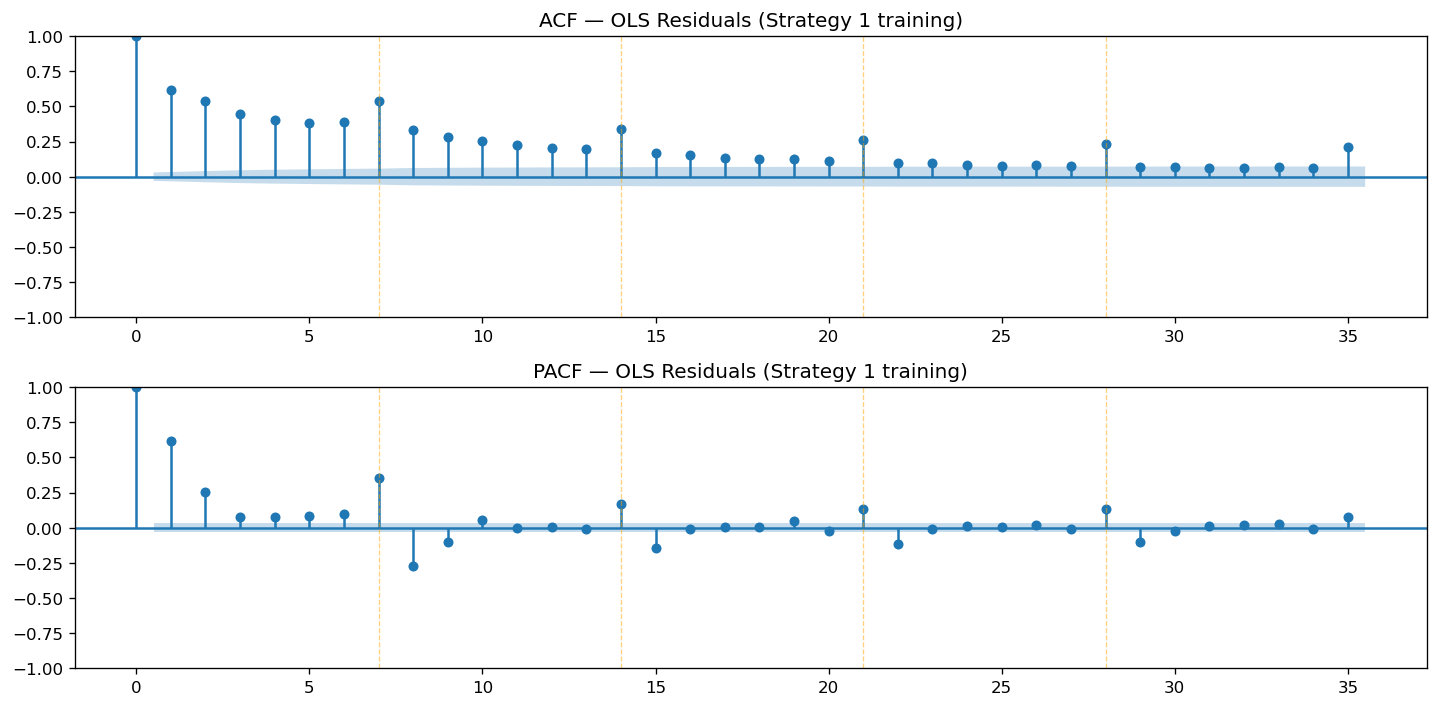

Saved: plots/sarima_acf_pacf.png

Orange dashed lines mark multiples of 7 (weekly seasonality lags).
Significant spikes at lag 7 → seasonal differencing (D=1) or seasonal AR/MA needed.


In [4]:
# ── ACF / PACF on OLS residuals ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

plot_acf(resid_s1_train, lags=35, ax=axes[0], title='ACF — OLS Residuals (Strategy 1 training)')
plot_pacf(resid_s1_train, lags=35, ax=axes[1], title='PACF — OLS Residuals (Strategy 1 training)')

for ax in axes:
    for lag in [7, 14, 21, 28]:
        ax.axvline(lag, color='orange', alpha=0.5, lw=0.8, ls='--')

plt.tight_layout()
plt.savefig('plots/sarima_acf_pacf.png', bbox_inches='tight')
plt.show()
print('Saved: plots/sarima_acf_pacf.png')
print()
print('Orange dashed lines mark multiples of 7 (weekly seasonality lags).')
print('Significant spikes at lag 7 → seasonal differencing (D=1) or seasonal AR/MA needed.')

In [5]:
# ── AIC grid search over candidate SARIMA orders ──────────────────────────
# Fixed seasonal component: (P,D,Q,s) = (0,1,1,7)
# Grid over non-seasonal (p,d,q)

SEASONAL_ORDER = (0, 1, 1, 7)

CANDIDATES = [
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 1),
    (1, 1, 1),
    (0, 1, 1),
]

aic_results = []
print(f'Fitting {len(CANDIDATES)} candidate models on Strategy 1 residuals...')
print(f'Seasonal order fixed: {SEASONAL_ORDER}')
print()

for order in CANDIDATES:
    t0 = time.time()
    try:
        m = SARIMAX(resid_s1_train, order=order, seasonal_order=SEASONAL_ORDER,
                    enforce_stationarity=False, enforce_invertibility=False)
        r = m.fit(disp=False)
        aic_results.append({'order': str(order), 'AIC': r.aic, 'BIC': r.bic,
                             'fit_time_s': round(time.time() - t0, 1)})
        print(f'  SARIMA{order}x{SEASONAL_ORDER}  AIC={r.aic:.1f}  BIC={r.bic:.1f}  [{time.time()-t0:.1f}s]')
    except Exception as e:
        print(f'  SARIMA{order}x{SEASONAL_ORDER}  FAILED: {e}')

aic_df = pd.DataFrame(aic_results).sort_values('AIC').reset_index(drop=True)
print()
print('Ranked by AIC:')
display(aic_df)

Fitting 6 candidate models on Strategy 1 residuals...
Seasonal order fixed: (0, 1, 1, 7)

  SARIMA(1, 0, 0)x(0, 1, 1, 7)  AIC=61109.4  BIC=61128.5  [2.4s]
  SARIMA(0, 0, 1)x(0, 1, 1, 7)  AIC=62392.6  BIC=62411.7  [1.7s]
  SARIMA(1, 0, 1)x(0, 1, 1, 7)  AIC=60898.1  BIC=60923.5  [3.4s]
  SARIMA(2, 0, 1)x(0, 1, 1, 7)  AIC=60885.8  BIC=60917.6  [7.0s]
  SARIMA(1, 1, 1)x(0, 1, 1, 7)  AIC=60998.0  BIC=61023.4  [7.5s]
  SARIMA(0, 1, 1)x(0, 1, 1, 7)  AIC=61134.6  BIC=61153.7  [3.1s]

Ranked by AIC:


,order,AIC,BIC,fit_time_s
0,"(2, 0, 1)",60885.770054,60917.561042,7.0
1,"(1, 0, 1)",60898.068033,60923.500823,3.4
2,"(1, 1, 1)",60997.969845,61023.401697,7.5
3,"(1, 0, 0)",61109.398208,61128.473504,2.4
4,"(0, 1, 1)",61134.592862,61153.666751,3.1
5,"(0, 0, 1)",62392.648717,62411.723310,1.7


In [6]:
# ── Select optimal SARIMA order ────────────────────────────────────────────
import ast
best_order_str = aic_df.iloc[0]['order']
BEST_ORDER = ast.literal_eval(best_order_str)

print(f'Selected SARIMA order : {BEST_ORDER}')
print(f'Seasonal order        : {SEASONAL_ORDER}')
print(f'Best AIC              : {aic_df.iloc[0]["AIC"]:.1f}')
print()

# Check AIC difference to second-best (parsimony check)
delta_aic = aic_df.iloc[1]['AIC'] - aic_df.iloc[0]['AIC']
print(f'ΔAIC to 2nd-best order: {delta_aic:.1f}')
if delta_aic < 2:
    print('  Note: ΔAIC < 2 → models are essentially equivalent; prefer simpler.')
else:
    print('  ΔAIC ≥ 2 → selected order has meaningful AIC advantage.')

Selected SARIMA order : (2, 0, 1)
Seasonal order        : (0, 1, 1, 7)
Best AIC              : 60885.8

ΔAIC to 2nd-best order: 12.3
  ΔAIC ≥ 2 → selected order has meaningful AIC advantage.


---
## Two-Stage Model Fitting

For each strategy:
1. Fit the Stage 1 regression on training data → coefficients β  
2. Compute residuals: `e_train = y_train − X_train · β`  
3. Fit `SARIMA(BEST_ORDER)(SEASONAL_ORDER)` on `e_train`

All four variants share the same SARIMA order, isolating the contribution of the predictor strategy.

In [7]:
# ── Helper functions ───────────────────────────────────────────────────────

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def nrmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return float(rmse / (y_true.max() - y_true.min()) * 100)  # as %


def fit_two_stage(X_tr, y_tr, stage1_model):
    """
    Fit Stage 1 regression and SARIMA on residuals.
    Returns (stage1_model_fitted, sarima_results, y_train_resid).
    """
    stage1 = stage1_model.fit(X_tr, y_tr)
    resid_tr = y_tr - stage1.predict(X_tr)

    sarima_m = SARIMAX(
        resid_tr, order=BEST_ORDER, seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False
    )
    sarima_r = sarima_m.fit(disp=False)

    return stage1, sarima_r, resid_tr


def rolling_evaluate(stage1, sarima_r, X_test, y_test, X_test_for_exog,
                     y_test_resid, horizons=HORIZONS, eval_step=15):
    """
    Rolling-origin multi-step evaluation.
    At each origin (every eval_step days), forecast h steps ahead for all h in horizons.
    Exogenous contribution at forecast time uses ACTUAL future X values (oracle scenario).

    Returns:
        metrics: dict {h: {'mape': float, 'nrmse': float, 'n_eval': int}}
        abs_errors: dict {h: np.ndarray of per-origin absolute errors}
                    Used downstream for Diebold-Mariano tests between strategies.
    """
    results = {h: {'preds': [], 'actuals': []} for h in horizons}

    # Exogenous demand contribution on test set
    exog_contrib_test = stage1.predict(X_test_for_exog)

    for origin in range(0, len(y_test_resid) - max(horizons), eval_step):
        # Extend SARIMA state to include test residuals up to origin
        if origin == 0:
            res_ext = sarima_r
        else:
            res_ext = sarima_r.append(endog=y_test_resid[:origin], refit=False)

        # Forecast MAX_H residual steps ahead
        fc_resid = res_ext.forecast(steps=max(horizons))

        for h in horizons:
            target_idx = origin + h
            if target_idx >= len(y_test_resid):
                continue
            pred_resid_h = fc_resid[h - 1]
            pred_demand  = pred_resid_h + exog_contrib_test[target_idx]
            actual_demand = y_test[target_idx]

            results[h]['preds'].append(pred_demand)
            results[h]['actuals'].append(actual_demand)

    metrics    = {}
    abs_errors = {}
    for h in horizons:
        p = np.array(results[h]['preds'])
        a = np.array(results[h]['actuals'])
        metrics[h] = {
            'mape': mape(a, p),
            'nrmse': nrmse(a, p),
            'n_eval': len(p)
        }
        abs_errors[h] = np.abs(a - p)  # per-origin absolute errors for DM tests

    return metrics, abs_errors


print('Helper functions defined.')

Helper functions defined.


---
## Strategy 0 — OLS-All (Unregularised Multicollinearity Baseline)

This model uses all 18 features with no regularisation. It is **expected to underperform** relative to strategies 1–4 because severe multicollinearity (GDP VIF≈2387) inflates and destabilises coefficients, reducing out-of-sample generalisation.

Its purpose is to make the multicollinearity problem empirically concrete: if SARIMAX-0 shows worse MAPE and more sign-inconsistent coefficients than SARIMAX-1 through 4, that directly motivates the strategy comparison.

In [8]:
# ── Strategy 0: OLS on ALL Features (Unregularised) ───────────────────────
print('Fitting SARIMAX-0 (OLS-All, unregularised multicollinearity baseline)...')
t0 = time.time()

s0_stage1, s0_sarima, s0_resid_train = fit_two_stage(
    X_ols_all['train'], y_train, LinearRegression()
)

print(f'  Stage 1 R²    : {s0_stage1.score(X_ols_all["train"], y_train):.4f}')
print(f'  SARIMA AIC    : {s0_sarima.aic:.1f}')
print(f'  Residual std  : {s0_resid_train.std():.1f} MW')
print(f'  Fit time      : {time.time()-t0:.1f}s')
print()
print('Note: SARIMAX-0 uses all 18 features with no regularisation. Higher R² than')
print('Strategy 1 (in-sample) but expected to generalise worse due to multicollinearity.')

Fitting SARIMAX-0 (OLS-All, unregularised multicollinearity baseline)...
  Stage 1 R²    : 0.8491
  SARIMA AIC    : 60865.3
  Residual std  : 492.5 MW
  Fit time      : 6.9s

Note: SARIMAX-0 uses all 18 features with no regularisation. Higher R² than
Strategy 1 (in-sample) but expected to generalise worse due to multicollinearity.


In [9]:
# ── Strategy 1: OLS on Correlation-Filtered Features ──────────────────────
print('Fitting SARIMAX-1 (Correlation Filter + OLS)...')
t0 = time.time()

s1_stage1, s1_sarima, s1_resid_train = fit_two_stage(
    X_filtered['train'], y_train, LinearRegression()
)

print(f'  Stage 1 R²    : {s1_stage1.score(X_filtered["train"], y_train):.4f}')
print(f'  SARIMA AIC    : {s1_sarima.aic:.1f}')
print(f'  Residual std  : {s1_resid_train.std():.1f} MW')
print(f'  Fit time      : {time.time()-t0:.1f}s')

Fitting SARIMAX-1 (Correlation Filter + OLS)...
  Stage 1 R²    : 0.8466
  SARIMA AIC    : 60885.8
  Residual std  : 496.6 MW
  Fit time      : 7.2s


In [10]:
# ── Strategy 2: OLS on PCA Components ────────────────────────────────────
print('Fitting SARIMAX-2 (PCA + OLS)...')
t0 = time.time()

s2_stage1, s2_sarima, s2_resid_train = fit_two_stage(
    X_pca['train'], y_train, LinearRegression()
)

print(f'  Stage 1 R²    : {s2_stage1.score(X_pca["train"], y_train):.4f}')
print(f'  SARIMA AIC    : {s2_sarima.aic:.1f}')
print(f'  Residual std  : {s2_resid_train.std():.1f} MW')
print(f'  Fit time      : {time.time()-t0:.1f}s')

Fitting SARIMAX-2 (PCA + OLS)...
  Stage 1 R²    : 0.8158
  SARIMA AIC    : 60875.4
  Residual std  : 544.1 MW
  Fit time      : 8.3s


In [11]:
# ── Strategy 3: Ridge Regression (L2) + SARIMA ───────────────────────────
print(f'Fitting SARIMAX-3 (Ridge λ={LAMBDA_RIDGE})...')
t0 = time.time()

s3_stage1, s3_sarima, s3_resid_train = fit_two_stage(
    X_ridge['train'], y_train,
    Ridge(alpha=LAMBDA_RIDGE, fit_intercept=True)
)

print(f'  Stage 1 R²    : {s3_stage1.score(X_ridge["train"], y_train):.4f}')
print(f'  SARIMA AIC    : {s3_sarima.aic:.1f}')
print(f'  Residual std  : {s3_resid_train.std():.1f} MW')
print(f'  Fit time      : {time.time()-t0:.1f}s')

Fitting SARIMAX-3 (Ridge λ=10.0)...
  Stage 1 R²    : 0.8486
  SARIMA AIC    : 60740.7
  Residual std  : 493.2 MW
  Fit time      : 10.2s


In [12]:
# ── Strategy 4: Elastic Net + SARIMA ─────────────────────────────────────
print(f'Fitting SARIMAX-4 (ElasticNet l1_ratio={L1_RATIO_ENET}, α={ALPHA_ENET})...')
t0 = time.time()

# Note: ElasticNet was fitted on scaled features in notebook 02
# Here we use unscaled features — refit with same hyperparameters
s4_stage1, s4_sarima, s4_resid_train = fit_two_stage(
    X_elasticnet['train'], y_train,
    ElasticNet(alpha=ALPHA_ENET, l1_ratio=L1_RATIO_ENET,
               max_iter=5000, fit_intercept=True)
)

print(f'  Stage 1 R²    : {s4_stage1.score(X_elasticnet["train"], y_train):.4f}')
print(f'  SARIMA AIC    : {s4_sarima.aic:.1f}')
print(f'  Residual std  : {s4_resid_train.std():.1f} MW')
print(f'  Fit time      : {time.time()-t0:.1f}s')

Fitting SARIMAX-4 (ElasticNet l1_ratio=1.0, α=0.01)...
  Stage 1 R²    : 0.8488
  SARIMA AIC    : 60844.1
  Residual std  : 493.0 MW
  Fit time      : 6.2s


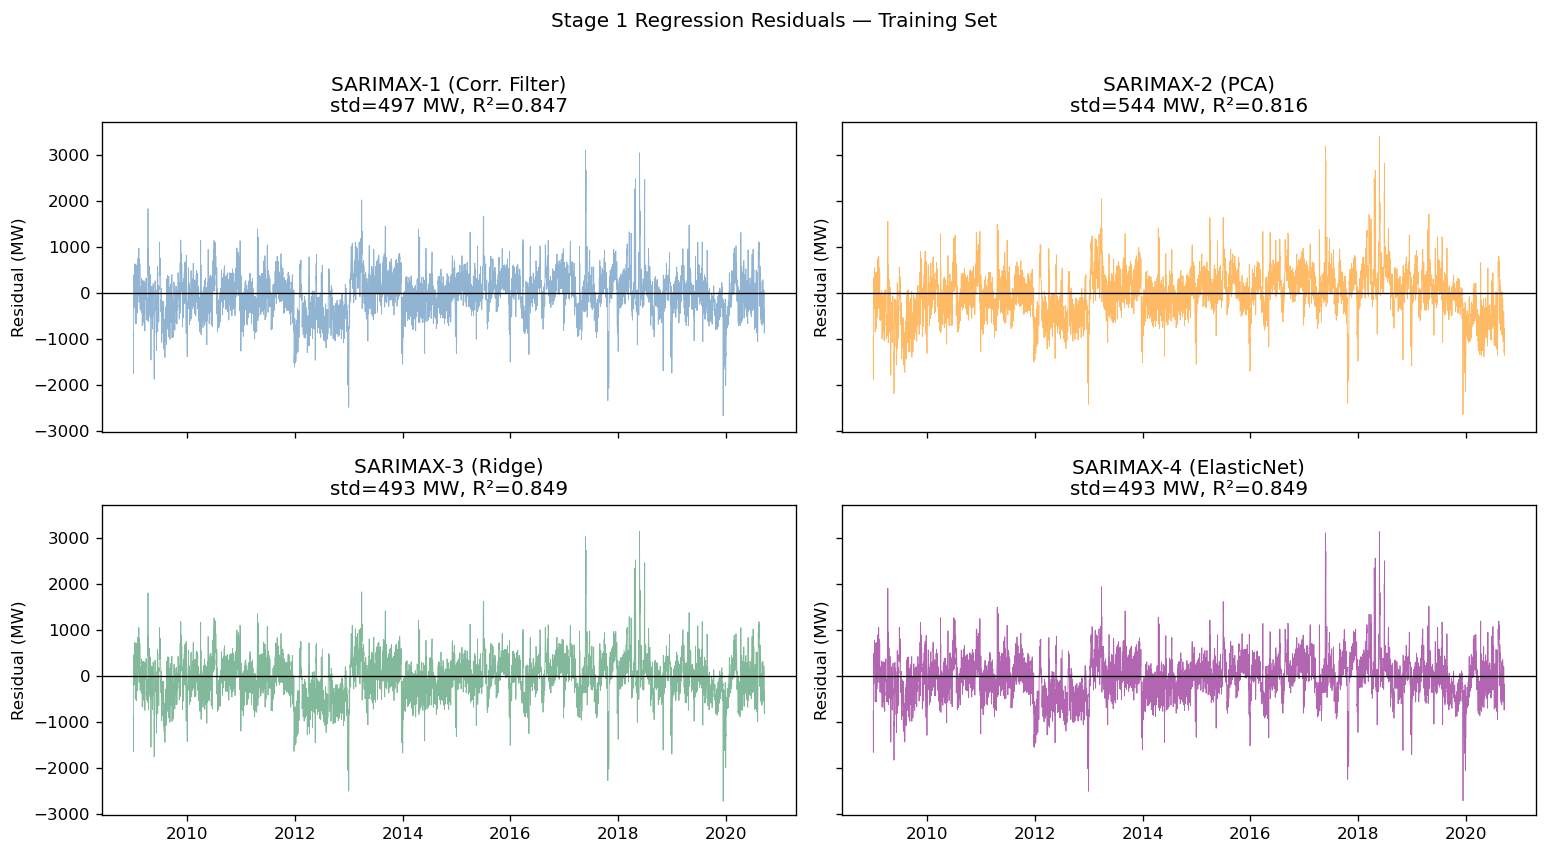

Saved: plots/stage1_residuals_comparison.png


In [13]:
# ── Stage 1 residual comparison (training) ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
configs = [
    (axes[0,0], s1_resid_train, 'SARIMAX-1 (Corr. Filter)', 'steelblue'),
    (axes[0,1], s2_resid_train, 'SARIMAX-2 (PCA)',          'darkorange'),
    (axes[1,0], s3_resid_train, 'SARIMAX-3 (Ridge)',        'seagreen'),
    (axes[1,1], s4_resid_train, 'SARIMAX-4 (ElasticNet)',   'purple'),
]

dates = train['date'].values
for ax, resid, title, color in configs:
    ax.plot(dates, resid, color=color, alpha=0.6, lw=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{title}\nstd={resid.std():.0f} MW, R²={1-(resid.var()/y_train.var()):.3f}')
    ax.set_ylabel('Residual (MW)')

plt.suptitle('Stage 1 Regression Residuals — Training Set', y=1.01)
plt.tight_layout()
plt.savefig('plots/stage1_residuals_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: plots/stage1_residuals_comparison.png')

---
## Multi-Step Forecast Evaluation

**Protocol:**
- **Rolling-origin evaluation** every 15 days through the test set → ~50 evaluation points per horizon  
- At each origin t, extend the SARIMA state (Kalman filter update, no refitting) and forecast h = 1, 3, 7, 30, 90, 180 steps ahead
- Actual future exogenous values are used at forecast time (oracle exog — isolates temporal forecasting error from predictor uncertainty)
- Metrics: MAPE (%) and nRMSE (%)

In [14]:
# ── Compute test residuals for each strategy ──────────────────────────────
# These are passed to rolling_evaluate() so the SARIMA state update
# conditions on actual demand residuals (not predicted).

s0_resid_test = y_test - s0_stage1.predict(X_ols_all['test'])
s1_resid_test = y_test - s1_stage1.predict(X_filtered['test'])
s2_resid_test = y_test - s2_stage1.predict(X_pca['test'])
s3_resid_test = y_test - s3_stage1.predict(X_ridge['test'])
s4_resid_test = y_test - s4_stage1.predict(X_elasticnet['test'])

print('Test residual statistics (MW):')
for name, r in [('S0-OLS-All', s0_resid_test), ('S1-Filter', s1_resid_test),
                ('S2-PCA', s2_resid_test), ('S3-Ridge', s3_resid_test),
                (f'S4-{S4_LABEL}', s4_resid_test)]:
    print(f'  {name}: mean={r.mean():.1f}, std={r.std():.1f}')

Test residual statistics (MW):
  S0-OLS-All: mean=1160.8, std=636.9
  S1-Filter: mean=650.2, std=665.8
  S2-PCA: mean=-846.4, std=659.0
  S3-Ridge: mean=1105.7, std=634.8
  S4-Lasso (l1=1.0): mean=1103.8, std=646.8


In [15]:
# ── Evaluate SARIMAX-0 (OLS-All, unregularised baseline) ──────────────────
print('Evaluating SARIMAX-0 (OLS-All)...')
t0 = time.time()
metrics_s0, errors_s0 = rolling_evaluate(
    s0_stage1, s0_sarima,
    X_ols_all['test'], y_test,
    X_ols_all['test'], s0_resid_test
)
print(f'  Done in {time.time()-t0:.1f}s')
for h, m in metrics_s0.items():
    print(f'  h={h:3d}d: MAPE={m["mape"]:.2f}%  nRMSE={m["nrmse"]:.2f}%  (n={m["n_eval"]})')

Evaluating SARIMAX-0 (OLS-All)...
  Done in 4.9s
  h=  1d: MAPE=2.53%  nRMSE=8.02%  (n=50)
  h=  3d: MAPE=3.35%  nRMSE=10.36%  (n=50)
  h=  7d: MAPE=4.35%  nRMSE=13.59%  (n=50)
  h= 30d: MAPE=4.92%  nRMSE=13.49%  (n=50)
  h= 90d: MAPE=5.50%  nRMSE=15.16%  (n=50)
  h=180d: MAPE=5.24%  nRMSE=15.31%  (n=50)


In [16]:
# ── Evaluate SARIMAX-1 ─────────────────────────────────────────────────────
print('Evaluating SARIMAX-1 (Correlation Filter)...')
t0 = time.time()
metrics_s1, errors_s1 = rolling_evaluate(
    s1_stage1, s1_sarima,
    X_filtered['test'], y_test,
    X_filtered['test'], s1_resid_test
)
print(f'  Done in {time.time()-t0:.1f}s')
for h, m in metrics_s1.items():
    print(f'  h={h:3d}d: MAPE={m["mape"]:.2f}%  nRMSE={m["nrmse"]:.2f}%  (n={m["n_eval"]})')

Evaluating SARIMAX-1 (Correlation Filter)...
  Done in 4.2s
  h=  1d: MAPE=2.52%  nRMSE=8.04%  (n=50)
  h=  3d: MAPE=3.44%  nRMSE=10.41%  (n=50)
  h=  7d: MAPE=4.49%  nRMSE=13.69%  (n=50)
  h= 30d: MAPE=4.69%  nRMSE=12.82%  (n=50)
  h= 90d: MAPE=5.05%  nRMSE=14.14%  (n=50)
  h=180d: MAPE=4.81%  nRMSE=13.80%  (n=50)


In [17]:
# ── Evaluate SARIMAX-2 ─────────────────────────────────────────────────────
print('Evaluating SARIMAX-2 (PCA)...')
t0 = time.time()
metrics_s2, errors_s2 = rolling_evaluate(
    s2_stage1, s2_sarima,
    X_pca['test'], y_test,
    X_pca['test'], s2_resid_test
)
print(f'  Done in {time.time()-t0:.1f}s')
for h, m in metrics_s2.items():
    print(f'  h={h:3d}d: MAPE={m["mape"]:.2f}%  nRMSE={m["nrmse"]:.2f}%  (n={m["n_eval"]})')

Evaluating SARIMAX-2 (PCA)...
  Done in 4.1s
  h=  1d: MAPE=2.69%  nRMSE=8.73%  (n=50)
  h=  3d: MAPE=3.95%  nRMSE=12.28%  (n=50)
  h=  7d: MAPE=4.42%  nRMSE=13.45%  (n=50)
  h= 30d: MAPE=4.53%  nRMSE=12.01%  (n=50)
  h= 90d: MAPE=4.99%  nRMSE=13.39%  (n=50)
  h=180d: MAPE=4.46%  nRMSE=12.57%  (n=50)


In [18]:
# ── Evaluate SARIMAX-3 ─────────────────────────────────────────────────────
print('Evaluating SARIMAX-3 (Ridge)...')
t0 = time.time()
metrics_s3, errors_s3 = rolling_evaluate(
    s3_stage1, s3_sarima,
    X_ridge['test'], y_test,
    X_ridge['test'], s3_resid_test
)
print(f'  Done in {time.time()-t0:.1f}s')
for h, m in metrics_s3.items():
    print(f'  h={h:3d}d: MAPE={m["mape"]:.2f}%  nRMSE={m["nrmse"]:.2f}%  (n={m["n_eval"]})')

Evaluating SARIMAX-3 (Ridge)...
  Done in 5.2s
  h=  1d: MAPE=2.44%  nRMSE=7.79%  (n=50)
  h=  3d: MAPE=3.33%  nRMSE=10.29%  (n=50)
  h=  7d: MAPE=4.28%  nRMSE=13.27%  (n=50)
  h= 30d: MAPE=4.80%  nRMSE=13.11%  (n=50)
  h= 90d: MAPE=5.36%  nRMSE=14.81%  (n=50)
  h=180d: MAPE=5.11%  nRMSE=14.81%  (n=50)


In [19]:
# ── Evaluate SARIMAX-4 (Lasso / Elastic Net) ──────────────────────────────
print(f'Evaluating SARIMAX-4 ({S4_LABEL})...')
t0 = time.time()
metrics_s4, errors_s4 = rolling_evaluate(
    s4_stage1, s4_sarima,
    X_elasticnet['test'], y_test,
    X_elasticnet['test'], s4_resid_test
)
print(f'  Done in {time.time()-t0:.1f}s')
for h, m in metrics_s4.items():
    print(f'  h={h:3d}d: MAPE={m["mape"]:.2f}%  nRMSE={m["nrmse"]:.2f}%  (n={m["n_eval"]})')

Evaluating SARIMAX-4 (Lasso (l1=1.0))...
  Done in 4.7s
  h=  1d: MAPE=2.52%  nRMSE=8.05%  (n=50)
  h=  3d: MAPE=3.41%  nRMSE=10.54%  (n=50)
  h=  7d: MAPE=4.21%  nRMSE=13.34%  (n=50)
  h= 30d: MAPE=4.84%  nRMSE=13.32%  (n=50)
  h= 90d: MAPE=5.46%  nRMSE=15.10%  (n=50)
  h=180d: MAPE=5.26%  nRMSE=15.37%  (n=50)


---
## Results Tables

In [20]:
# ── Build consolidated results tables ─────────────────────────────────────
MODELS = {
    'SARIMAX-0 (OLS-All)':    metrics_s0,
    'SARIMAX-1 (Filter)':     metrics_s1,
    'SARIMAX-2 (PCA)':        metrics_s2,
    'SARIMAX-3 (Ridge)':      metrics_s3,
    f'SARIMAX-4 ({S4_LABEL})': metrics_s4,
}

# Load baseline results from notebook 01
baselines = pd.read_csv('data/baseline_results.csv')
baseline_dict = baselines.set_index('Horizon (days)').to_dict()

rows_mape  = []
rows_nrmse = []

# Add baselines
for bl_name, col in [('Seasonal Naive', 'SeasonalNaive MAPE (%)'),
                      ('OLS-Temperature', 'OLS-Temp MAPE (%)')]:
    row = {'Model': bl_name}
    row_n = {'Model': bl_name}
    for h in HORIZONS:
        if h in baseline_dict.get(col, {}):
            row[f'h={h}d'] = round(baseline_dict[col][h], 2)
        else:
            row[f'h={h}d'] = None
        if h in baseline_dict.get('SeasonalNaive nRMSE (%)', {}):
            row_n[f'h={h}d'] = round(baseline_dict['SeasonalNaive nRMSE (%)'][h], 2) if bl_name == 'Seasonal Naive' else None
    rows_mape.append(row)
    rows_nrmse.append(row_n)

# Add SARIMAX models
for model_name, metrics in MODELS.items():
    row_m = {'Model': model_name}
    row_n = {'Model': model_name}
    for h in HORIZONS:
        row_m[f'h={h}d'] = round(metrics[h]['mape'],  2)
        row_n[f'h={h}d'] = round(metrics[h]['nrmse'], 2)
    rows_mape.append(row_m)
    rows_nrmse.append(row_n)

mape_df  = pd.DataFrame(rows_mape)
nrmse_df = pd.DataFrame(rows_nrmse)

print('=== MAPE (%) — lower is better ===')
display(mape_df.set_index('Model'))
print()
print('=== nRMSE (%) — lower is better ===')
display(nrmse_df.set_index('Model'))
print()
print('SARIMAX-0 (OLS-All) is the unregularised baseline. Higher MAPE than')
print('mitigated strategies confirms that multicollinearity degrades accuracy.')

=== MAPE (%) — lower is better ===


,h=1d,h=3d,h=7d,h=30d,h=90d,h=180d
Model,,,,,,
Seasonal Naive,4.17,4.17,4.17,6.13,9.39,11.71
OLS-Temperature,7.85,7.85,7.85,7.85,7.85,7.85
SARIMAX-0 (OLS-All),2.53,3.35,4.35,4.92,5.50,5.24
SARIMAX-1 (Filter),2.52,3.44,4.49,4.69,5.05,4.81
SARIMAX-2 (PCA),2.69,3.95,4.42,4.53,4.99,4.46
SARIMAX-3 (Ridge),2.44,3.33,4.28,4.80,5.36,5.11
SARIMAX-4 (Lasso (l1=1.0)),2.52,3.41,4.21,4.84,5.46,5.26



=== nRMSE (%) — lower is better ===


,h=1d,h=3d,h=7d,h=30d,h=90d,h=180d
Model,,,,,,
Seasonal Naive,9.67,9.67,9.67,13.40,19.99,24.62
OLS-Temperature,NaN,NaN,NaN,NaN,NaN,NaN
SARIMAX-0 (OLS-All),8.02,10.36,13.59,13.49,15.16,15.31
SARIMAX-1 (Filter),8.04,10.41,13.69,12.82,14.14,13.80
SARIMAX-2 (PCA),8.73,12.28,13.45,12.01,13.39,12.57
SARIMAX-3 (Ridge),7.79,10.29,13.27,13.11,14.81,14.81
SARIMAX-4 (Lasso (l1=1.0)),8.05,10.54,13.34,13.32,15.10,15.37



SARIMAX-0 (OLS-All) is the unregularised baseline. Higher MAPE than
mitigated strategies confirms that multicollinearity degrades accuracy.


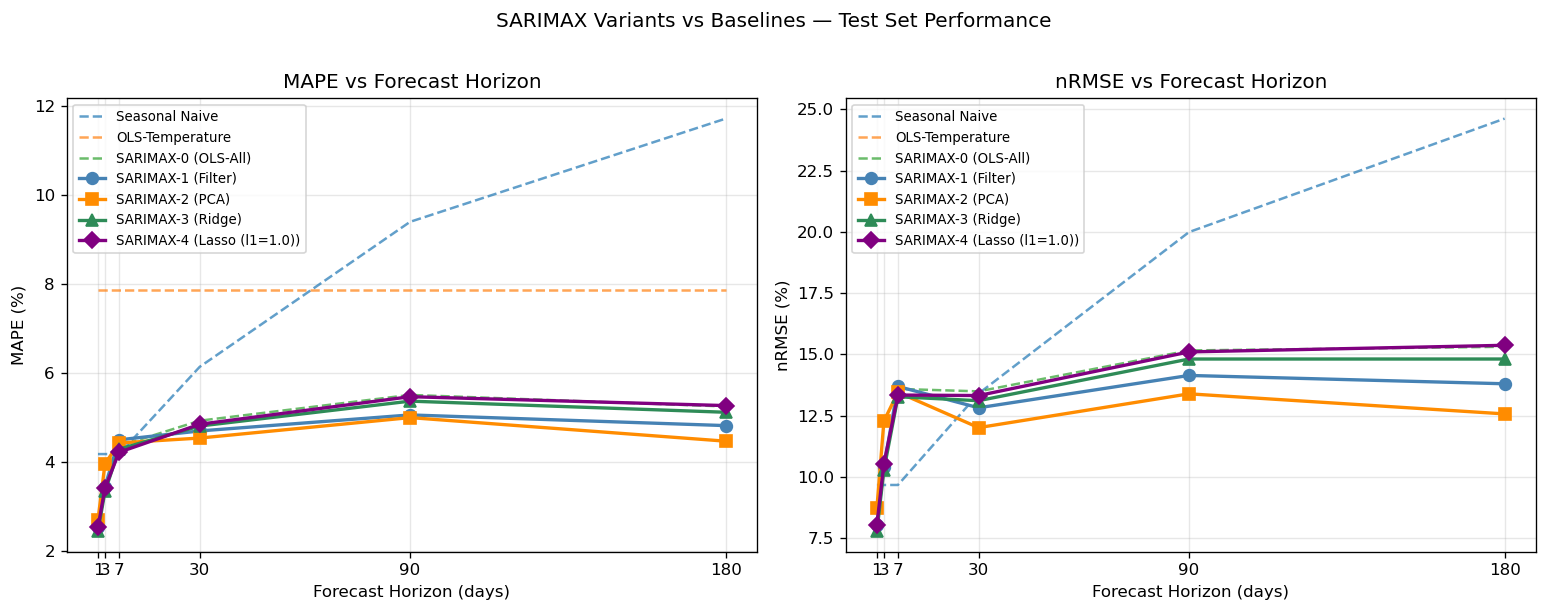

Saved: plots/sarimax_mape_vs_horizon.png


In [21]:
# ── MAPE vs Horizon line plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['steelblue', 'darkorange', 'seagreen', 'purple']
styles = ['-o', '-s', '-^', '-D']

for ax, df, ylabel, title in [
    (axes[0], mape_df,  'MAPE (%)',  'MAPE vs Forecast Horizon'),
    (axes[1], nrmse_df, 'nRMSE (%)', 'nRMSE vs Forecast Horizon'),
]:
    h_cols = [f'h={h}d' for h in HORIZONS]

    # Plot baselines with dashed lines
    for i, row in df[df['Model'].str.contains('Naive|OLS')].iterrows():
        vals = [row[c] for c in h_cols]
        if any(v is not None for v in vals):
            ax.plot(HORIZONS, vals, '--', alpha=0.7, label=row['Model'], lw=1.5)

    # Plot SARIMAX models
    sarimax_rows = df[~df['Model'].str.contains('Naive|OLS')]
    for (_, row), color, style in zip(sarimax_rows.iterrows(), colors, styles):
        vals = [row[c] for c in h_cols]
        ax.plot(HORIZONS, vals, style, color=color, label=row['Model'],
                lw=2, ms=7)

    ax.set_xlabel('Forecast Horizon (days)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(HORIZONS)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('SARIMAX Variants vs Baselines — Test Set Performance', y=1.01)
plt.tight_layout()
plt.savefig('plots/sarimax_mape_vs_horizon.png', bbox_inches='tight')
plt.show()
print('Saved: plots/sarimax_mape_vs_horizon.png')

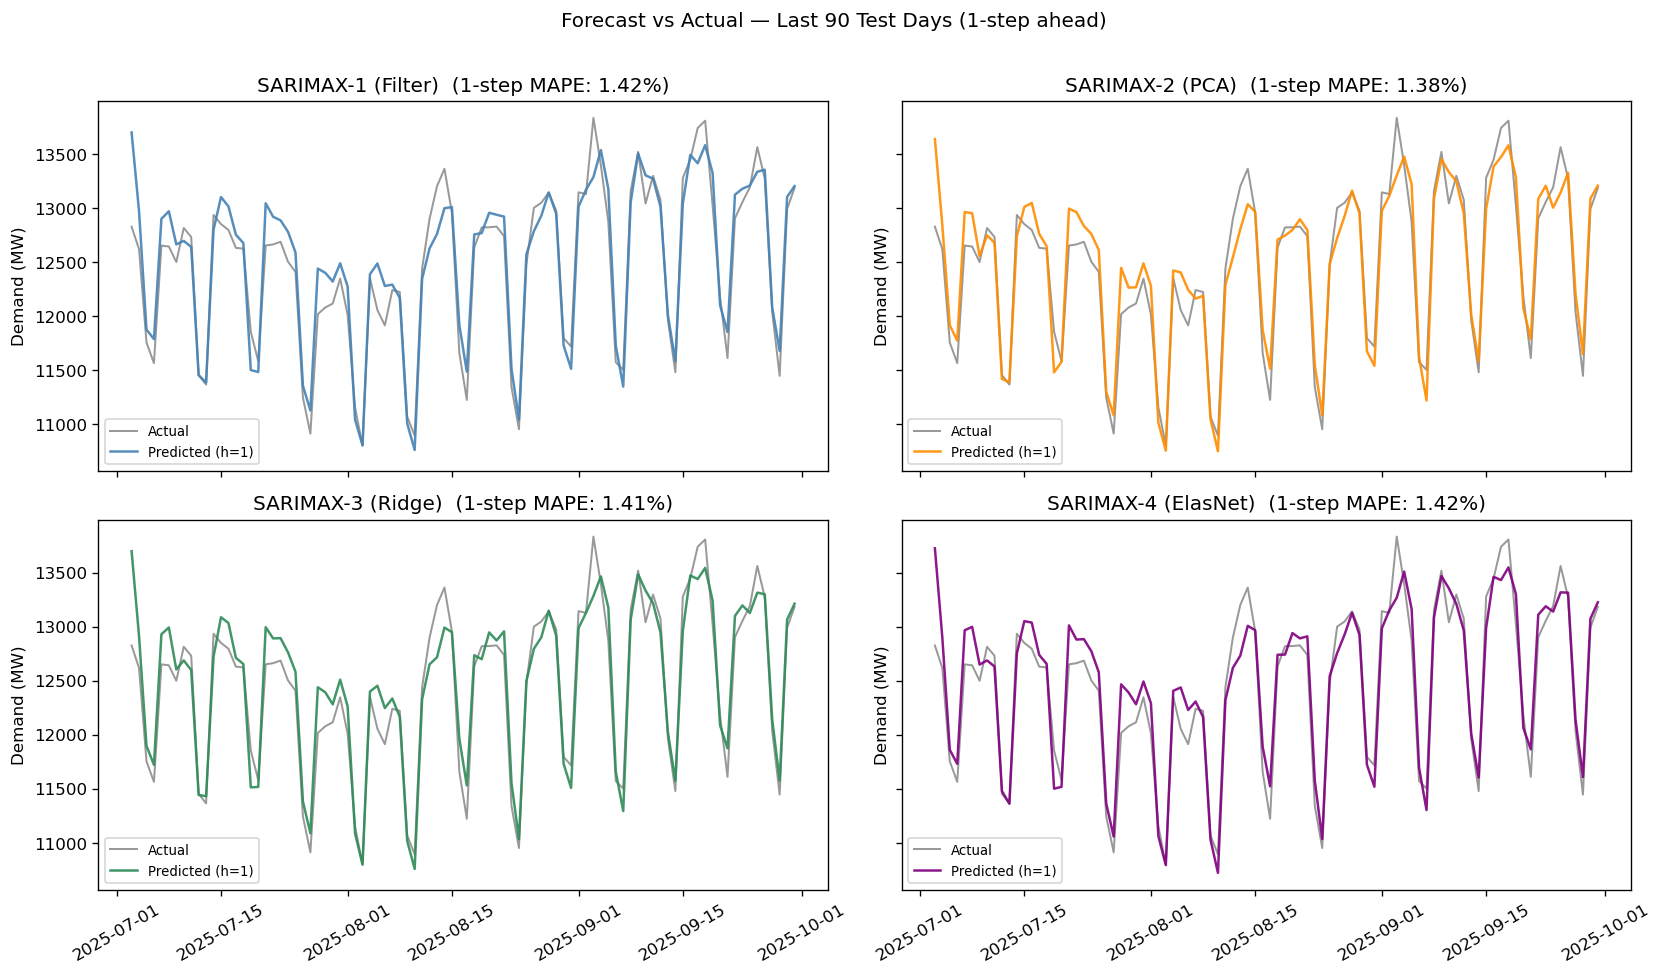

Saved: plots/sarimax_forecast_vs_actual.png


In [22]:
# ── Forecast vs actual — last 90 days of test set (h=1, each strategy) ────
# Use the rolling eval predictions at h=1 to reconstruct forecast trajectories

def get_h1_predictions(stage1, sarima_r, X_te, y_te, resid_te):
    """Get day-by-day 1-step ahead predictions for the test set."""
    # Extend SARIMA to include all test residuals
    sarima_ext = sarima_r.append(endog=resid_te, refit=False)
    # In-sample predictions for the appended data (true 1-step ahead)
    fitted = sarima_ext.fittedvalues
    resid_pred = fitted[-len(y_te):]  # last N = test period
    exog_pred  = stage1.predict(X_te)
    return resid_pred + exog_pred

PLOT_DAYS = 90
test_dates = test['date'].values[-PLOT_DAYS:]
actual_tail = y_test[-PLOT_DAYS:]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
configs = [
    (axes[0,0], s1_stage1, s1_sarima, X_filtered, s1_resid_test, 'SARIMAX-1 (Filter)',  'steelblue'),
    (axes[0,1], s2_stage1, s2_sarima, X_pca,      s2_resid_test, 'SARIMAX-2 (PCA)',     'darkorange'),
    (axes[1,0], s3_stage1, s3_sarima, X_ridge,    s3_resid_test, 'SARIMAX-3 (Ridge)',   'seagreen'),
    (axes[1,1], s4_stage1, s4_sarima, X_elasticnet,s4_resid_test,'SARIMAX-4 (ElasNet)', 'purple'),
]

for ax, stage1, sarima_r, X_dict, resid_te, name, color in configs:
    preds = get_h1_predictions(stage1, sarima_r, X_dict['test'], y_test, resid_te)
    ax.plot(test_dates, actual_tail, color='gray', lw=1.2, alpha=0.8, label='Actual')
    ax.plot(test_dates, preds[-PLOT_DAYS:], color=color, lw=1.5, alpha=0.9, label='Predicted (h=1)')
    mape_1 = mape(actual_tail, preds[-PLOT_DAYS:])
    ax.set_title(f'{name}  (1-step MAPE: {mape_1:.2f}%)')
    ax.set_ylabel('Demand (MW)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Forecast vs Actual — Last 90 Test Days (1-step ahead)', y=1.01)
plt.tight_layout()
plt.savefig('plots/sarimax_forecast_vs_actual.png', bbox_inches='tight')
plt.show()
print('Saved: plots/sarimax_forecast_vs_actual.png')

---
## SARIMA Residual Diagnostics

Check whether the SARIMA component has adequately captured temporal autocorrelation. Ljung-Box test on model residuals (null: no autocorrelation up to lag k).

Ljung-Box test (lags=7,14,21,28) on SARIMA residuals:
  Null hypothesis: no autocorrelation in residuals
  p > 0.05 → fail to reject null → residuals are white noise (desired)

  SARIMAX-1 (Filter):
    lag= 7 p=0.000✗  lag=14 p=0.000✗  lag=21 p=0.000✗  lag=28 p=0.000✗
  SARIMAX-2 (PCA):
    lag= 7 p=0.000✗  lag=14 p=0.000✗  lag=21 p=0.000✗  lag=28 p=0.000✗
  SARIMAX-3 (Ridge):
    lag= 7 p=0.000✗  lag=14 p=0.000✗  lag=21 p=0.000✗  lag=28 p=0.000✗
  SARIMAX-4 (ElasNet):
    lag= 7 p=0.000✗  lag=14 p=0.000✗  lag=21 p=0.000✗  lag=28 p=0.000✗


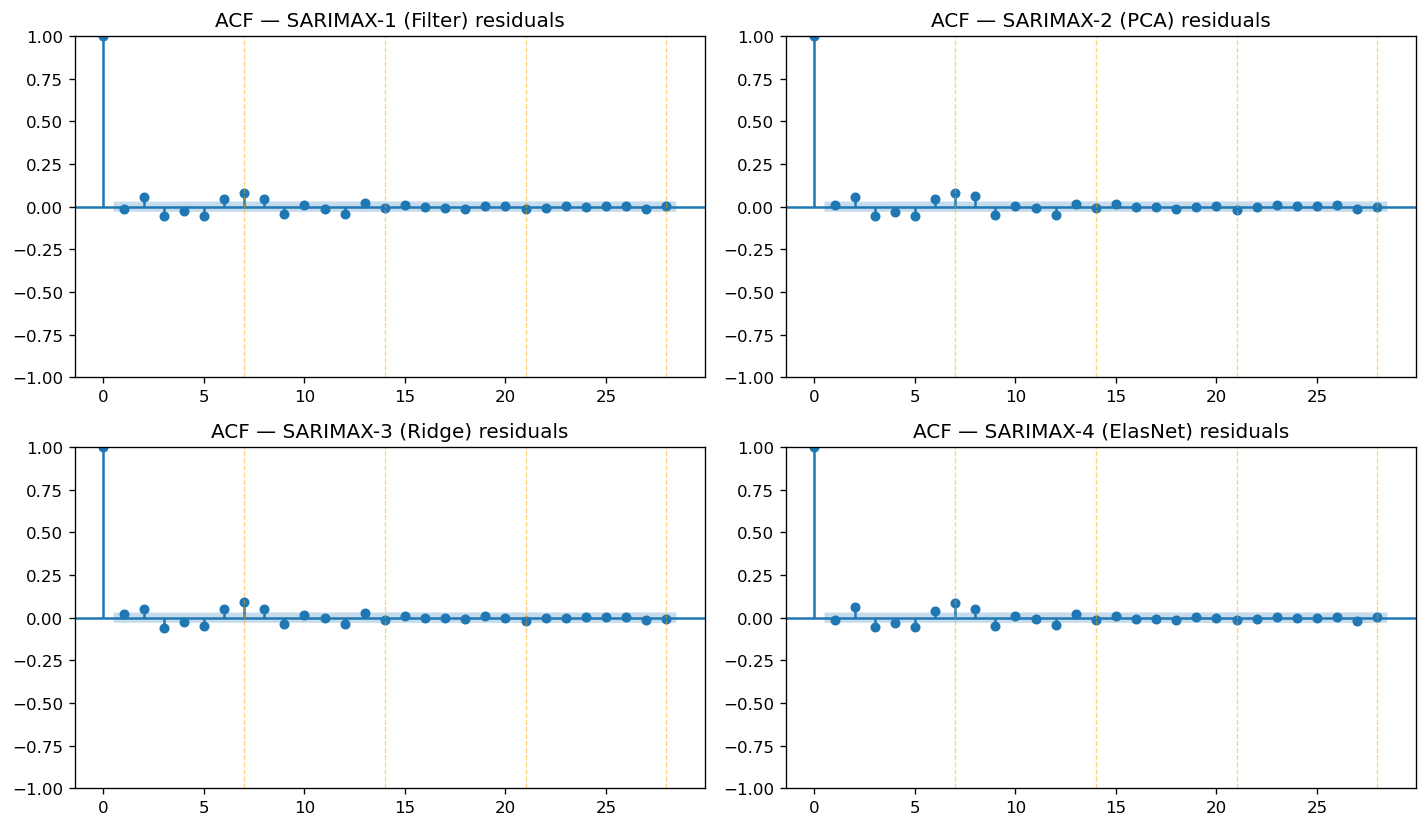


Saved: plots/sarimax_residual_acf.png


In [23]:
# ── Ljung-Box test on SARIMA residuals ────────────────────────────────────
print('Ljung-Box test (lags=7,14,21,28) on SARIMA residuals:')
print(f'  Null hypothesis: no autocorrelation in residuals')
print(f'  p > 0.05 → fail to reject null → residuals are white noise (desired)')
print()

for name, sarima_r in [
    ('SARIMAX-1 (Filter)',  s1_sarima),
    ('SARIMAX-2 (PCA)',     s2_sarima),
    ('SARIMAX-3 (Ridge)',   s3_sarima),
    ('SARIMAX-4 (ElasNet)', s4_sarima),
]:
    res_resid = sarima_r.resid
    lb = acorr_ljungbox(res_resid, lags=[7, 14, 21, 28], return_df=True)
    p7  = lb['lb_pvalue'].iloc[0]
    p14 = lb['lb_pvalue'].iloc[1]
    p21 = lb['lb_pvalue'].iloc[2]
    p28 = lb['lb_pvalue'].iloc[3]
    status7  = '✓' if p7  > 0.05 else '✗'
    status14 = '✓' if p14 > 0.05 else '✗'
    status21 = '✓' if p21 > 0.05 else '✗'
    status28 = '✓' if p28 > 0.05 else '✗'
    print(f'  {name}:')
    print(f'    lag= 7 p={p7:.3f}{status7}  lag=14 p={p14:.3f}{status14}  lag=21 p={p21:.3f}{status21}  lag=28 p={p28:.3f}{status28}')

# Residual ACF plots for all four models
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (name, sarima_r) in zip(
    axes.flatten(),
    [('SARIMAX-1 (Filter)', s1_sarima), ('SARIMAX-2 (PCA)', s2_sarima),
     ('SARIMAX-3 (Ridge)', s3_sarima),  ('SARIMAX-4 (ElasNet)', s4_sarima)]
):
    plot_acf(sarima_r.resid, lags=28, ax=ax,
             title=f'ACF — {name} residuals')
    for lag in [7, 14, 21, 28]:
        ax.axvline(lag, color='orange', alpha=0.5, lw=0.8, ls='--')

plt.tight_layout()
plt.savefig('plots/sarimax_residual_acf.png', bbox_inches='tight')
plt.show()
print('\nSaved: plots/sarimax_residual_acf.png')

---
## Stage 1 Coefficient Analysis

The key interpretability comparison: how do coefficient signs and magnitudes differ across strategies? This feeds directly into notebook 04's coefficient stability analysis.

In [24]:
# ── Stage 1 coefficients: OLS-All vs Filter vs Ridge vs Lasso ─────────────
# PCA excluded (components not interpretable in original feature space)

# Get feature names for each strategy
filtered_df = pd.read_csv('data/strategy_filtered_train.csv')
ridge_df    = pd.read_csv('data/strategy_ridge_train.csv')
enet_df     = pd.read_csv('data/strategy_elasticnet_train.csv')

filtered_features = [c for c in filtered_df.columns if c != 'date']
ridge_features    = [c for c in ridge_df.columns if c != 'date']
enet_features     = [c for c in enet_df.columns if c != 'date']
ols_all_features  = ridge_features  # same 18 features as Ridge

coef_s0 = dict(zip(ols_all_features, s0_stage1.coef_))   # OLS-All
coef_s1 = dict(zip(filtered_features, s1_stage1.coef_))  # Filter
coef_s3 = dict(zip(ridge_features,    s3_stage1.coef_))  # Ridge
coef_s4 = dict(zip(enet_features,     s4_stage1.coef_))  # Lasso

# Build comparison dataframe
all_feats = sorted(set(coef_s0) | set(coef_s1) | set(coef_s3) | set(coef_s4))
coef_compare = pd.DataFrame({
    'Feature': all_feats,
    'OLS-All (S0)':  [coef_s0.get(f, np.nan) for f in all_feats],
    'Filter (S1)':   [coef_s1.get(f, np.nan) for f in all_feats],
    'Ridge (S3)':    [coef_s3.get(f, np.nan) for f in all_feats],
    f'{S4_LABEL} (S4)': [coef_s4.get(f, np.nan) for f in all_feats],
}).set_index('Feature').round(2)

print('Stage 1 Coefficient Comparison (original feature space):')
print('  NaN = feature removed/absent | 0.00 = zeroed by Lasso | values in MW per standardised unit')
print()
print('Key diagnostic: OLS-All coefficients are expected to be inflated and sign-inconsistent')
print('compared to Ridge/Lasso, due to multicollinearity (GDP VIF≈2387, population VIF≈1983).')
display(coef_compare)

Stage 1 Coefficient Comparison (original feature space):
  NaN = feature removed/absent | 0.00 = zeroed by Lasso | values in MW per standardised unit

Key diagnostic: OLS-All coefficients are expected to be inflated and sign-inconsistent
compared to Ridge/Lasso, due to multicollinearity (GDP VIF≈2387, population VIF≈1983).


,OLS-All (S0),Filter (S1),Ridge (S3),Lasso (l1=1.0) (S4)
Feature,,,,
cloudiness,-23.59,9.97,-20.30,NaN
cos1_ann,748.03,653.47,711.98,747.53
cos2_ann,301.38,353.51,300.20,291.81
day_of_week,-2.29,-1.82,-11.60,-2.20
gdp_mln_eur,352.39,637.60,346.80,303.40
global_rad,31.18,-112.82,1.64,40.66
humidity_pct,-28.30,-28.73,-26.72,NaN
is_holiday,-1608.15,-1606.51,-1476.70,-1604.92
is_weekend,-1787.11,-1788.91,-1735.01,-1786.28


---
## Save Results

In [25]:
# ── Save all evaluation results ────────────────────────────────────────────
import os

# Full results table (MAPE and nRMSE)
all_rows = []
for model_name, metrics in MODELS.items():
    for h in HORIZONS:
        all_rows.append({
            'model': model_name,
            'horizon_days': h,
            'mape_pct': round(metrics[h]['mape'], 4),
            'nrmse_pct': round(metrics[h]['nrmse'], 4),
            'n_eval_points': metrics[h]['n_eval']
        })

results_df = pd.DataFrame(all_rows)
results_df.to_csv('data/sarimax_results.csv', index=False)

# MAPE and nRMSE tables
mape_df.to_csv('data/sarimax_mape_table.csv', index=False)
nrmse_df.to_csv('data/sarimax_nrmse_table.csv', index=False)

# SARIMA order
order_info = {
    'order': list(BEST_ORDER),
    'seasonal_order': list(SEASONAL_ORDER),
    'selection_criterion': 'AIC',
    'aic': float(aic_df.iloc[0]['AIC'])
}
with open('data/sarima_order.json', 'w') as f:
    json.dump(order_info, f, indent=2)

# Stage 1 coefficients
coef_compare.to_csv('data/sarimax_stage1_coefs.csv')

# Summary: best model per horizon (among mitigated strategies only, excluding S0 baseline)
mitigated_df = results_df[~results_df['model'].str.contains('OLS-All')]
best_per_h = mitigated_df.loc[mitigated_df.groupby('horizon_days')['mape_pct'].idxmin(),
                               ['horizon_days', 'model', 'mape_pct', 'nrmse_pct']]
best_per_h.to_csv('data/sarimax_best_per_horizon.csv', index=False)

outputs = ['data/sarimax_results.csv', 'data/sarimax_mape_table.csv',
           'data/sarimax_nrmse_table.csv', 'data/sarima_order.json',
           'data/sarimax_stage1_coefs.csv', 'data/sarimax_best_per_horizon.csv']

print('Saved outputs:')
for f in outputs:
    size = os.path.getsize(f) // 1024
    print(f'  ✓  {size:>3} KB  {f}')

print()
print('Best SARIMAX model per horizon (mitigated strategies only, by MAPE):')
display(best_per_h)

Saved outputs:
  ✓    1 KB  data/sarimax_results.csv
  ✓    0 KB  data/sarimax_mape_table.csv
  ✓    0 KB  data/sarimax_nrmse_table.csv
  ✓    0 KB  data/sarima_order.json
  ✓    0 KB  data/sarimax_stage1_coefs.csv
  ✓    0 KB  data/sarimax_best_per_horizon.csv

Best SARIMAX model per horizon (mitigated strategies only, by MAPE):


,horizon_days,model,mape_pct,nrmse_pct
18,1,SARIMAX-3 (Ridge),2.4354,7.7878
19,3,SARIMAX-3 (Ridge),3.3308,10.2903
26,7,SARIMAX-4 (Lasso (l1=1.0)),4.2131,13.3419
15,30,SARIMAX-2 (PCA),4.5323,12.0121
16,90,SARIMAX-2 (PCA),4.9944,13.3930
17,180,SARIMAX-2 (PCA),4.4581,12.5704


---
## Diebold-Mariano Tests — Pairwise Strategy Comparison

To determine whether accuracy differences between strategies are **statistically significant**, we apply the Diebold-Mariano (DM) test with Harvey-Leybourne-Newbold (HLN) small-sample correction at each horizon.

- **Null hypothesis (H₀):** equal predictive accuracy between two strategies
- **Alternative (one-sided):** strategy A has lower absolute error than strategy B
- **p < 0.05** → reject H₀ → the difference is statistically significant

This is critical for H1: the claim that Ridge/ElasticNet achieve *comparable* accuracy to Filtering must be tested, not just asserted from point estimates.

In [26]:
from scipy import stats as scipy_stats

def dm_test_hln(e1, e2, h):
    """
    Diebold-Mariano test with Harvey-Leybourne-Newbold small-sample correction.

    e1, e2 : arrays of per-origin absolute forecast errors (same length n)
    h      : forecast horizon (used for HLN correction)

    Returns (dm_stat, p_value_two_sided, p_value_e1_better).
    Positive dm_stat → e1 > e2 on average → model 2 is better.
    """
    d = e1 - e2   # loss differential; positive → model 1 is worse
    n = len(d)
    if n < 3:
        return np.nan, np.nan, np.nan
    d_bar    = d.mean()
    gamma0   = np.var(d, ddof=1)
    # HLN correction factor (accounts for autocorrelation in loss differential)
    hln_factor = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_stat  = d_bar / (np.sqrt(gamma0 / n) * hln_factor)
    p_two    = 2 * (1 - scipy_stats.t.cdf(abs(dm_stat), df=n-1))
    p_e1_better = scipy_stats.t.cdf(-dm_stat, df=n-1)   # one-sided: e1 < e2
    return float(dm_stat), float(p_two), float(p_e1_better)


# Strategy error dicts keyed by horizon
strategy_errors = {
    'OLS-All': errors_s0,
    'Filter':  errors_s1,
    'PCA':     errors_s2,
    'Ridge':   errors_s3,
    S4_LABEL:  errors_s4,
}

# Key pairs for thesis:
#   H0 baseline: OLS-All vs Filter, OLS-All vs Ridge (shows mitigation improves accuracy)
#   H1: Filter vs Ridge, Filter vs Lasso, Ridge vs Lasso
#   H2: Filter vs PCA (reduction strategies), PCA vs Ridge (info loss)
pairs = [
    ('OLS-All', 'Filter'),   # baseline: does filtering help vs doing nothing?
    ('OLS-All', 'Ridge'),    # baseline: does Ridge help vs doing nothing?
    ('Filter',  'Ridge'),
    ('Filter',  S4_LABEL),
    ('Ridge',   S4_LABEL),
    ('Filter',  'PCA'),
    ('PCA',     'Ridge'),
]

dm_rows = []
print('Diebold-Mariano Tests (HLN correction)')
print('Positive DM stat → column A has larger errors (column B is better)\n')
print(f'{"Pair":<40}  {"Horizon":>8}  {"DM stat":>9}  {"p (two-sided)":>14}  {"p (B better)":>13}  {"sig":>4}')
print('-' * 100)

for s_a, s_b in pairs:
    e_a = strategy_errors[s_a]
    e_b = strategy_errors[s_b]
    for h in HORIZONS:
        # Align lengths (in case of boundary differences)
        n = min(len(e_a[h]), len(e_b[h]))
        dm, p_two, p_b_better = dm_test_hln(e_a[h][:n], e_b[h][:n], h)
        sig = ('**' if p_two < 0.05 else ('.' if p_two < 0.10 else ''))
        print(f'{s_a:<16} vs {s_b:<16}  h={h:3d}d  {dm:+9.3f}  {p_two:>14.4f}  {p_b_better:>13.4f}  {sig:>4}')
        dm_rows.append({
            'strategy_A': s_a, 'strategy_B': s_b,
            'horizon_days': h,
            'dm_stat': round(dm, 4) if not np.isnan(dm) else None,
            'p_two_sided': round(p_two, 4) if not np.isnan(p_two) else None,
            'p_B_better': round(p_b_better, 4) if not np.isnan(p_b_better) else None,
            'significant_5pct': bool(p_two < 0.05) if not np.isnan(p_two) else None,
        })
    print()

dm_df = pd.DataFrame(dm_rows)
dm_df.to_csv('data/sarimax_dm_tests.csv', index=False)
print('Saved: data/sarimax_dm_tests.csv')
print('\nLegend: ** p<0.05  . p<0.10  (blank) not significant')

Diebold-Mariano Tests (HLN correction)
Positive DM stat → column A has larger errors (column B is better)

Pair                                       Horizon    DM stat   p (two-sided)   p (B better)   sig
----------------------------------------------------------------------------------------------------
OLS-All          vs Filter            h=  1d     +0.092          0.9267         0.4633      
OLS-All          vs Filter            h=  3d     -1.187          0.2409         0.8796      
OLS-All          vs Filter            h=  7d     -1.222          0.2277         0.8862      
OLS-All          vs Filter            h= 30d     +3.946          0.0003         0.0001    **
OLS-All          vs Filter            h= 90d     +3.074          0.0034         0.0017    **
OLS-All          vs Filter            h=180d     +0.700          0.4873         0.2436      

OLS-All          vs Ridge             h=  1d     +2.041          0.0467         0.0234    **
OLS-All          vs Ridge             h= 